In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
import pdb
from tqdm import tqdm
import re

print('GOGOGO!')

GOGOGO!


In [2]:
# Get all available font families
font_families = matplotlib.font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

# Print the font families
print("Available Font Families:")
for font_path in font_families:
    try:
        font_property = matplotlib.font_manager.FontProperties(fname=font_path)
        font_family = font_property.get_name()
        print(font_family)
    except Exception as e:
        print(f"Error processing font file {font_path}: {e}")


Available Font Families:
STKaiti
Leelawadee UI
Lucida Sans Typewriter
Ebrima
Copperplate Gothic Light
Garamond
Bodoni MT
Corbel
Cambria
Playbill
MS Reference Specialty
Lucida Sans Unicode
Yu Gothic
Gill Sans MT
Bahnschrift
Vivaldi
Castellar
Gloucester MT Extra Condensed
Agency FB
Elephant
Calisto MT
High Tower Text
Candara
Franklin Gothic Medium Cond
Bookman Old Style
Verdana
Tw Cen MT
LiSu
Century
Century Schoolbook
Lucida Console
Rockwell Condensed
Euclid
Euclid Math One
Franklin Gothic Medium
Palace Script MT
Bodoni MT
Cambria
Book Antiqua
Malgun Gothic
Microsoft Tai Le
Lucida Sans Typewriter
Goudy Old Style
Bell MT
Euclid
Javanese Text
Calibri
Bell MT
Lucida Bright
Euclid
Bodoni MT
Lucida Bright
Rockwell
Wide Latin
Comic Sans MS
Microsoft Tai Le
Candara
Malgun Gothic
Lucida Handwriting
Agency FB
Corbel
Verdana
Tw Cen MT Condensed
Calibri
Corbel
Magneto
French Script MT
Rockwell
Perpetua
Segoe Script
Modern No. 20
Algerian
Segoe UI Variable
Bell MT
Perpetua
Cooper Black
Broadway
Com

[None, None, None, None, 2.829e-06, None, 5.1173e-06, None, None, None, None, None, None, None, None, None, None, None, None, None, 1.6913e-09, None, 7.0786e-06, None, None, None, None, None, None, None, None, None, None, None, None, 1.1081e-05, None, None, None, None, None, None, 1.6488e-05, None, None, None, None, None, None, None, None, None, None, 7.6044e-05, None, 0.0001, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 1.083e-05, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 0.0001, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, 2.1812e-05, None, None, None, None, 4.2194e-05, None, None, None, None, None, 1.7244e-05, None, None, None, None, None, None, None, None, None, None, None, None, None, 1.0022e-05, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, N

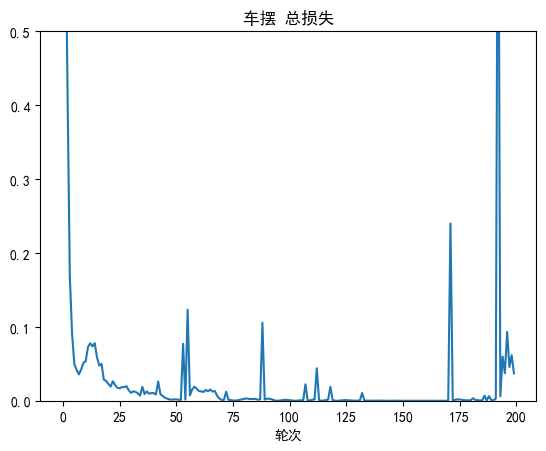

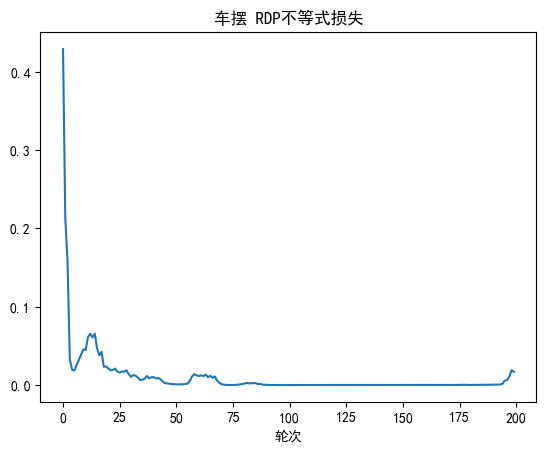

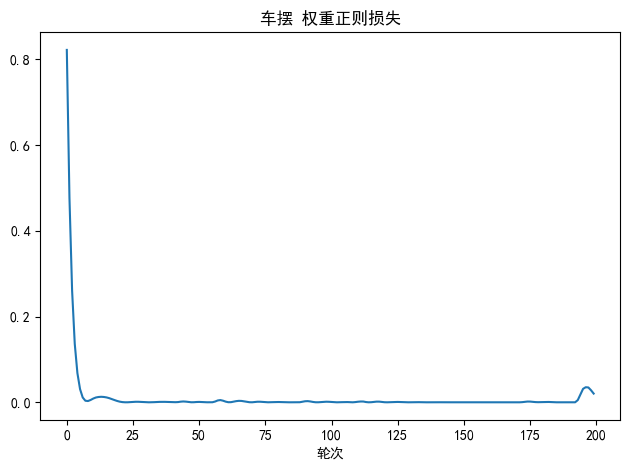

In [15]:
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus']=False  # 用来正常显示负号
def parse_log_file(log_file_path):
    """
    Parses a log file to extract training data (epoch, loss, rdp loss, weight penalty, lyap loss).

    Args:
        log_file_path (str): The path to the log file.

    Returns:
        dict: A dictionary containing lists of epoch numbers, loss values, rdp loss values,
              weight penalty values, and Lyapunov loss values.  Returns empty lists if no data is found.
    """

    epochs = []
    losses = []
    rdp_losses = []
    rdp_points = []
    weight_penalties = []
    lyap_losses = []

    with open(log_file_path, 'r') as f:
        for line in f:
            # Updated regex pattern to handle None in Lyap loss
            match = re.search(r"Epoch: (\d+), loss: ([\d\.e\-\+]+) rdp loss: ([\d\.e\-\+]+), RDP Points: ([\d\.e\-\+]+), weight penalty: ([\d\.e\-\+]+), Lyap loss: (None|tensor\(\[([\d\.e\-\+]+)\])", line)
            if match:
                epoch = int(match.group(1))
                loss = float(match.group(2))
                rdp_loss = float(match.group(3))
                rdp_point = float(match.group(4))
                weight_penalty = float(match.group(5))
                
                # Handle Lyap loss which could be None
                if match.group(6) == 'None':
                    lyap_loss = None
                else:
                    lyap_loss = float(match.group(7))

                epochs.append(epoch)
                losses.append(loss)
                rdp_losses.append(rdp_loss)
                rdp_points.append(rdp_point)
                weight_penalties.append(weight_penalty)
                lyap_losses.append(lyap_loss)

    return {
        'epochs': epochs,
        'losses': losses,
        'rdp_losses': rdp_losses,
        'rdp_points': rdp_points,
        'weight_penalties': weight_penalties,
        'lyap_losses': lyap_losses
    }

    # epochs = []
    # losses = []
    # rdp_losses = []
    # weight_penalties = []
    # lyap_losses = []

    # with open(log_file_path, 'r') as f:
    #     for line in f:
    #         # Use regular expressions to extract the data
    #         match = re.search(r"Epoch: (\d+), loss: ([\d\.]+).*?rdp loss: ([\d\.]+).*?weight penalty: ([\d\.]+).*?Lyap loss: tensor\(\[([\d\.e\-\+]+)\].*", line)
    #         if match:
    #             epoch = int(match.group(1))
    #             loss = float(match.group(2))
    #             rdp_loss = float(match.group(3))
    #             weight_penalty = float(match.group(4))
    #             lyap_loss = float(match.group(5))

    #             epochs.append(epoch)
    #             losses.append(loss)
    #             rdp_losses.append(rdp_loss)
    #             weight_penalties.append(weight_penalty)
    #             lyap_losses.append(lyap_loss)

    # return {
    #     'epochs': epochs,
    #     'losses': losses,
    #     'rdp_losses': rdp_losses,
    #     'weight_penalties': weight_penalties,
    #     'lyap_losses': lyap_losses
    # }


def plot_training_data(data, title_prefix="车摆"):
    """
    Plots the training data (loss, rdp loss, weight penalty, Lyapunov loss) against epoch.

    Args:
        data (dict): A dictionary containing lists of epoch numbers, loss values, rdp loss values,
                     weight penalty values, and Lyapunov loss values, as returned by parse_log_file.
        title_prefix (str, optional): Prefix for the plot titles. Defaults to "Training".
    """

    epochs = data['epochs']
    losses = data['losses']
    rdp_losses = data['rdp_losses']
    weight_penalties = data['weight_penalties']
    lyap_losses = data['lyap_losses']

    if not epochs:
        print("No data to plot.")
        return

    plt.figure()
    plt.plot(losses)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} 总损失')
    plt.ylim(0, 0.5)

    plt.figure()
    plt.plot(rdp_losses)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} RDP不等式损失')

    plt.figure()
    plt.plot(weight_penalties)
    plt.xlabel('轮次')
    plt.title(f'{title_prefix} 权重正则损失')

    # plt.figure()
    # lyap_losses = [loss / 1000 for loss in lyap_losses]
    # plt.plot(lyap_losses)
    # plt.xlabel('轮次')
    # plt.title(f'{title_prefix} 李雅普诺夫不等式损失')
    print(lyap_losses)

    plt.tight_layout()  # Adjust subplot parameters for a tight layout.

log_file_path = 'D:/Docs/code_lib/graduation_test/testCartPole/2505171_Diag_QF_seed1_T25_FullRange/logger.txt'  # Replace with the actual path to your log file
training_data = parse_log_file(log_file_path)
plot_training_data(training_data)